# Materials EDA

Explores packaging permeability rows: uniques, missingness, outliers, unit mix, and whether values can be compared to food OTR/WVTR requirement bands.

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12

import sys

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)


def unique_report(df, max_levels=40):
    rows = []
    for col in df.columns:
        s = df[col]
        n_unique = s.nunique(dropna=False)
        n_missing = int(s.isna().sum())
        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "n_unique": n_unique,
            "n_missing": n_missing,
            "pct_missing": round(100 * n_missing / len(df), 2),
        })
        print(f"\n=== {col}  ({s.dtype})  unique={n_unique}  missing={n_missing} ===")
        vc = s.value_counts(dropna=False)
        if n_unique <= max_levels:
            display(vc.to_frame("count"))
        else:
            print(f"High cardinality — top {max_levels}:")
            display(vc.head(max_levels).to_frame("count"))
    return pd.DataFrame(rows)


def iqr_outliers(series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return s, np.nan, np.nan
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return s[(s < lo) | (s > hi)], lo, hi


def wvtr_to_g_m2_day(value, unit):
    if pd.isna(value) or pd.isna(unit):
        return np.nan
    u = str(unit).strip().lower().replace(" ", "")
    if u in {"g/m2day", "g/m2/day", "gm/m2day"}:
        return float(value)
    if u in {"g/m2s", "g/m2/s", "gm/m2s"}:
        return float(value) * 86400.0
    return np.nan


def otr_to_cm3_m2_day(value, unit):
    if pd.isna(value) or pd.isna(unit):
        return np.nan
    u = str(unit).strip().lower().replace(" ", "")
    if u in {"cm3/m2day", "cm3/m2/day"}:
        return float(value)
    if u in {"cm3/m2s", "cm3/m2/s"}:
        return float(value) * 86400.0
    return np.nan


In [5]:
mat_raw = pd.read_csv(ROOT / "data/raw/packaging_materials/materials_permeability.csv")
mat = pd.read_csv(ROOT / "data/processed/materials_permeability_enriched.csv")
reqs = pd.read_csv(ROOT / "data/raw/packaging_materials/food_requirements.csv")

print("raw", mat_raw.shape, "enriched", mat.shape)
display(mat.head())
display(mat.dtypes.to_frame("dtype"))


raw (296, 7) enriched (296, 10)


,Base Material,Type,Secondary Material,WVTR,OTR,WVTR unit,OTR unit,is_commercial_fpm,is_biobased_compostable,is_active_nanocomposite
0,fish gelatin,individual,none,2731.39776,NaN,g/m2day,NaN,False,False,False
1,fish gelatin,nanocomposite,montmorillonite,709.11288,NaN,g/m2day,NaN,False,False,False
2,fish gelatin,nanocomposite,montmorillonite,980.50176,NaN,g/m2day,NaN,False,False,False
3,fish gelatin,nanocomposite,montmorillonite,1199.36376,NaN,g/m2day,NaN,False,False,False
4,fish gelatin,nanocomposite,montmorillonite,1365.69888,NaN,g/m2day,NaN,False,False,False


,dtype
Base Material,object
Type,object
Secondary Material,object
WVTR,float64
OTR,float64
WVTR unit,object
OTR unit,object
is_commercial_fpm,bool
is_biobased_compostable,bool
is_active_nanocomposite,bool


## Unique values and counts
Every column: cardinality, missingness, and value counts (top 40 if high cardinality).

In [6]:
col_summary = unique_report(mat)
display(col_summary)



=== Base Material  (object)  unique=35  missing=0 ===


,count
Base Material,
polylactic acid,38
carrot puree,36
chitosan,32
polypropylene,22
methylcellulose,20
fish gelatin,17
polyurethane,11
polyethylene,10
fruit,9



=== Type  (object)  unique=6  missing=0 ===


,count
Type,
individual,139
nanocomposite,63
blend,46
coated,45
bilayer,2
indiviudal,1



=== Secondary Material  (object)  unique=22  missing=0 ===


...


=== is_biobased_compostable  (bool)  unique=2  missing=0 ===


,count
is_biobased_compostable,
False,167
True,129



=== is_active_nanocomposite  (bool)  unique=2  missing=0 ===


,count
is_active_nanocomposite,
False,252
True,44


,column,dtype,n_unique,n_missing,pct_missing
0,Base Material,object,35,0,0.00
1,Type,object,6,0,0.00
2,Secondary Material,object,22,0,0.00
3,WVTR,float64,140,155,52.36
4,OTR,float64,113,184,62.16
5,WVTR unit,object,3,155,52.36
6,OTR unit,object,6,184,62.16
7,is_commercial_fpm,bool,2,0,0.00
8,is_biobased_compostable,bool,2,0,0.00
9,is_active_nanocomposite,bool,2,0,0.00


## Missing values
WVTR and OTR are often measured on different samples, so missing one rate is expected. Missing **unit** should track missing **value**.

,fraction_missing
OTR unit,0.621622
OTR,0.621622
WVTR unit,0.523649
WVTR,0.523649
Type,0.000000
Base Material,0.000000
Secondary Material,0.000000
is_commercial_fpm,0.000000
is_biobased_compostable,0.000000
is_active_nanocomposite,0.000000


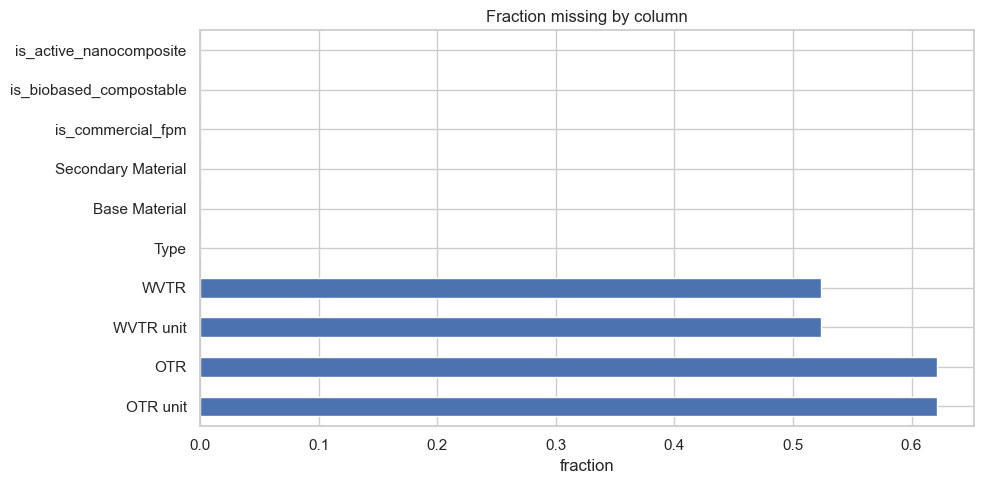

WVTR present, unit missing: 0
OTR present, unit missing: 0


TypeError: cannot convert the series to <class 'int'>

In [7]:
miss = mat.isna().mean().sort_values(ascending=False).to_frame("fraction_missing")
display(miss)
fig, ax = plt.subplots()
miss["fraction_missing"].plot(kind="barh", ax=ax)
ax.set_title("Fraction missing by column")

ax.set_xlabel("fraction")
plt.tight_layout()
plt.show()

print("WVTR present, unit missing:", int(mat["WVTR"].notna().eq(True).mul(mat["WVTR unit"].isna()).sum()))
print("OTR present, unit missing:", int(mat["OTR"].notna().eq(True).mul(mat["OTR unit"].isna()).sum()))
print("both WVTR and OTR present:", int(mat["WVTR"].notna() & mat["OTR"].notna()))
print("neither present:", int(mat["WVTR"].isna() & mat["OTR"].isna()))


## Categorical distinctions
`Type` has a likely typo (`indiviudal`). Flags come from `prepare_data.py`.

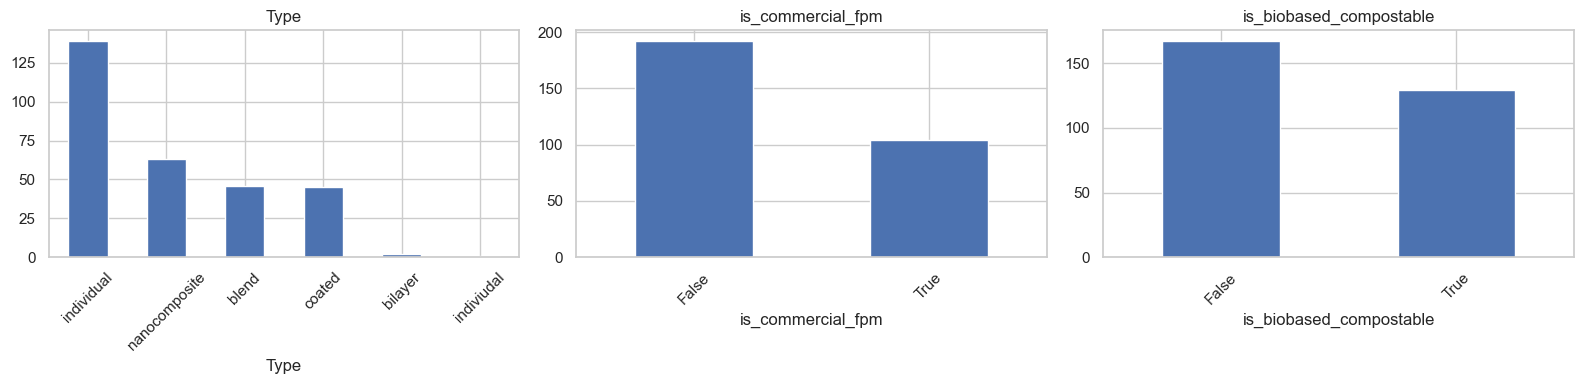

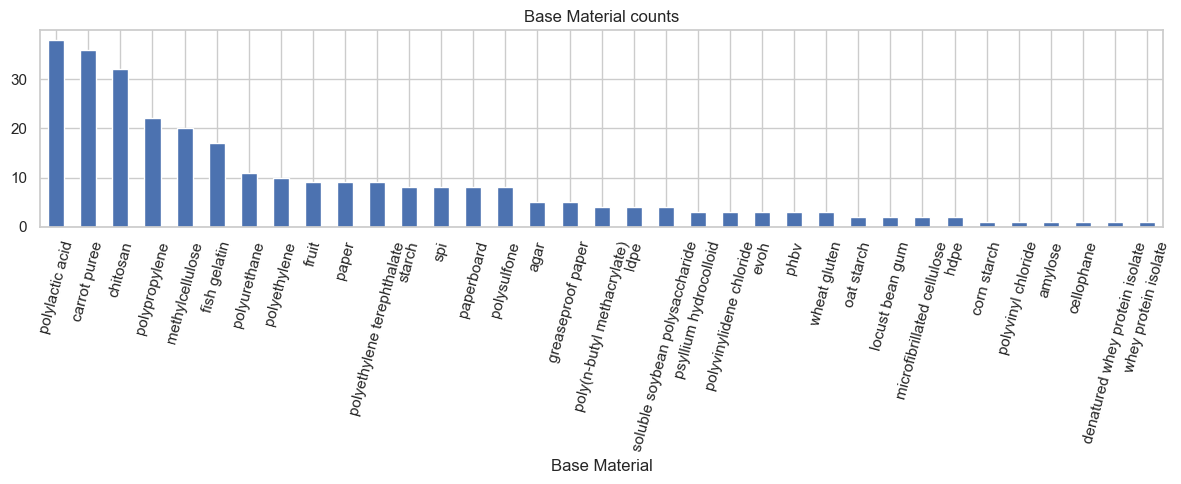

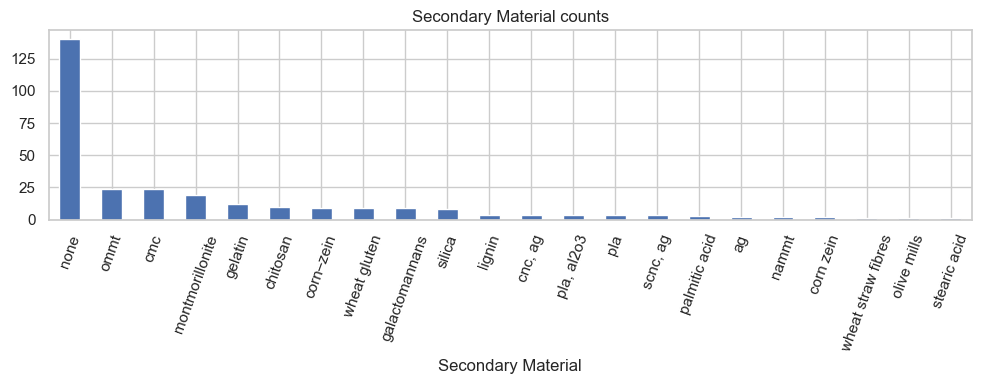

,is_commercial_fpm,is_biobased_compostable,is_active_nanocomposite
Type,,,
bilayer,0.000,0.000,0.000
blend,0.000,0.130,0.000
coated,0.689,0.489,0.000
individual,0.309,0.568,0.000
indiviudal,0.000,1.000,0.000
nanocomposite,0.476,0.333,0.698


is_biobased_compostable,False,True
is_commercial_fpm,,
False,123,69
True,44,60


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Type", "is_commercial_fpm", "is_biobased_compostable"]):
    mat[col].value_counts(dropna=False).plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
mat["Base Material"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Base Material counts")
ax.tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
mat["Secondary Material"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Secondary Material counts")
ax.tick_params(axis="x", rotation=70)
plt.tight_layout()
plt.show()

flag_cols = ["is_commercial_fpm", "is_biobased_compostable", "is_active_nanocomposite"]
display(mat.groupby("Type")[flag_cols].mean().round(3))
display(pd.crosstab(mat["is_commercial_fpm"], mat["is_biobased_compostable"]))


## Units — materials are **not** all in one unit
Food requirement CSV has **no unit column**. Typical food-packaging literature uses WVTR in `g/m2/day` and OTR in `cm3/m2/day`. Materials still contain other units, so raw numbers must not be mixed.

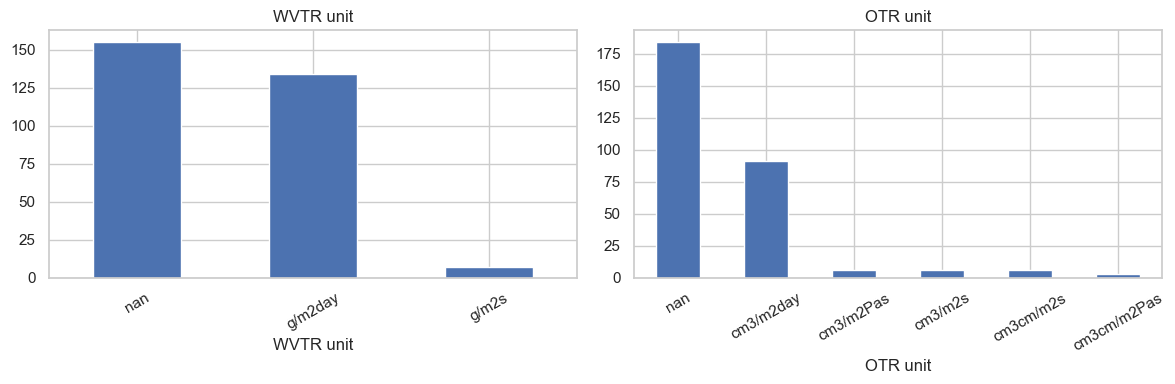

Food requirement columns: ['Food_Category', 'Min_OTR', 'Max_OTR', 'Min_WVTR', 'Max_WVTR', 'Description']
Food requirement table has unit fields: False


,Food_Category,Min_OTR,Max_OTR,Min_WVTR,Max_WVTR,Description
0,"Fruits, Vegetables, Salads",10000.0,200000.0,10.0,3000.0,High respiration; requires gas exchange to sta...
1,Bakery products,30.0,4000.0,600.0,3000.0,High moisture transmission needed to avoid sog...
2,Cheese,7.0,10.0,300.0,600.0,Narrow moisture range to maintain texture.
3,"Meat, MAP",2.0,20.0,10.0,50.0,Modified atmosphere packaging for processed me...
4,"Fresh meat, MAP",20.0,40.0,2.0,4.0,"Low moisture loss, controlled oxygen for color..."
5,Peanuts,0.7,10.0,2.0,8.0,Low O2 to prevent rancidity; low WVTR for crun...
6,Instant coffee,0.2,2.0,0.7,3.0,High barrier required for aroma and clumping p...
7,Baby food,0.1,1.0,0.5,2.0,Nutritional Integrity
8,Edible Oils and Fats,0.1,2.0,1.0,10.0,O2 barrier critical to prevent lipid oxidation...


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mat["WVTR unit"].value_counts(dropna=False).plot(kind="bar", ax=axes[0], title="WVTR unit")
mat["OTR unit"].value_counts(dropna=False).plot(kind="bar", ax=axes[1], title="OTR unit")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

print("Food requirement columns:", list(reqs.columns))
print("Food requirement table has unit fields:", any("unit" in c.lower() for c in reqs.columns))
display(reqs)


## Raw numeric stats and IQR outliers
Extreme max values are usually **unit artifacts** (per-second or permeability coefficients), not extreme films.

,WVTR,OTR
count,1.410000e+02,1.120000e+02
mean,1.249103e+08,2.818754e+17
std,1.341044e+09,2.975388e+18
min,2.969213e-06,2.314815e-10
1%,3.227917e-06,1.490741e-09
5%,1.925986e+01,6.255208e-08
25%,1.000000e+03,2.530045e-01
50%,1.915042e+04,1.215997e+01
75%,1.084739e+05,2.778653e+03
95%,3.351215e+05,4.847560e+07


WVTR: IQR fences [-1.602e+05, 2.697e+05]  n_outliers=15  min=270801.42716857616  max=15907940697.6
OTR: IQR fences [-4167, 6946]  n_outliers=23  min=6958.936152  max=3.1489172288313508e+19


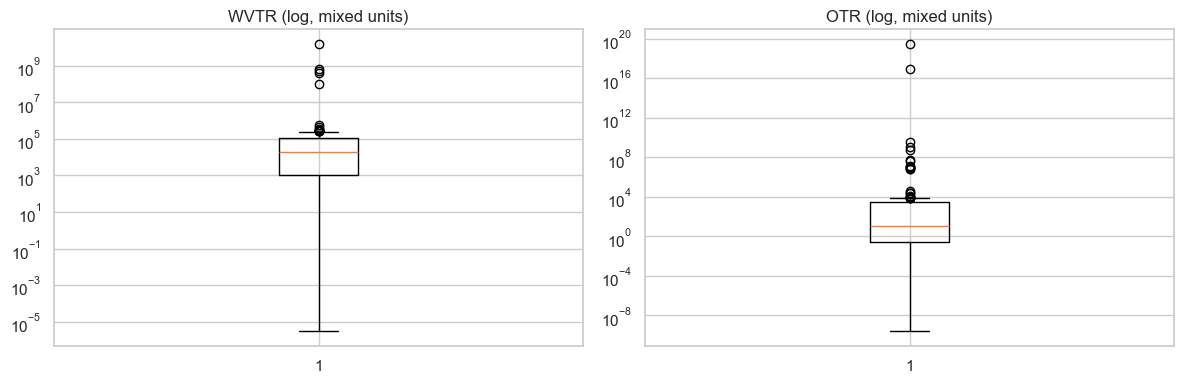


WVTR by unit:


,count,mean,std,min,25%,50%,75%,max
WVTR unit,,,,,,,,
g/m2day,134.0,1.314355e+08,1.375568e+09,19.259856,1201.552380,21072.548329,117290.888478,1.590794e+10
g/m2s,7.0,3.863757e-06,8.134415e-07,0.000003,0.000003,0.000004,0.000004,5.203472e-06
NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


OTR by unit:


,count,mean,std,min,25%,50%,75%,max
OTR unit,,,,,,,,
cm3/m2Pas,6.0,3.001543e-08,3.379270e-08,2.314815e-10,1.620370e-09,2.430556e-08,4.803241e-08,8.125000e-08
cm3/m2day,91.0,3.469235e+17,3.300879e+18,1.600000e-05,4.697319e+00,9.197411e+01,6.940552e+03,3.148917e+19
cm3/m2s,6.0,1.009259e-02,6.664420e-03,5.393519e-03,5.998264e-03,8.217593e-03,9.794560e-03,2.314815e-02
cm3cm/m2Pas,3.0,1.268248e-06,2.109296e-06,2.708333e-08,5.052083e-08,7.395833e-08,1.888831e-06,3.703704e-06
cm3cm/m2s,6.0,2.228009e-05,7.808427e-06,1.458333e-05,1.710069e-05,1.984954e-05,2.589699e-05,3.530093e-05
NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
display(mat[["WVTR", "OTR"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

for col in ["WVTR", "OTR"]:
    outs, lo, hi = iqr_outliers(mat[col])
    print(f"{col}: IQR fences [{lo:.4g}, {hi:.4g}]  n_outliers={len(outs)}  min={outs.min() if len(outs) else '—'}  max={outs.max() if len(outs) else '—'}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["WVTR", "OTR"]):
    s = pd.to_numeric(mat[col], errors="coerce").dropna()
    ax.boxplot(s, vert=True)
    ax.set_yscale("log")
    ax.set_title(f"{col} (log, mixed units)")
plt.tight_layout()
plt.show()

print("\nWVTR by unit:")
display(mat.groupby("WVTR unit", dropna=False)["WVTR"].describe())
print("OTR by unit:")
display(mat.groupby("OTR unit", dropna=False)["OTR"].describe())


## Convert comparable rows to food-like units
- `g/m2s` → `g/m2day` by ×86400
- `cm3/m2s` → `cm3/m2day` by ×86400
- `cm3/m2Pas`, `cm3cm/m2s`, `cm3cm/m2Pas` need thickness/pressure and are **not** converted here

In [11]:
mat["WVTR_g_m2_day"] = [wvtr_to_g_m2_day(v, u) for v, u in zip(mat["WVTR"], mat["WVTR unit"])]
mat["OTR_cm3_m2_day"] = [otr_to_cm3_m2_day(v, u) for v, u in zip(mat["OTR"], mat["OTR unit"])]
mat["wvtr_comparable"] = mat["WVTR_g_m2_day"].notna()
mat["otr_comparable"] = mat["OTR_cm3_m2_day"].notna()

print("WVTR convertible to g/m2day:", int(mat["wvtr_comparable"].sum()), "/", mat["WVTR"].notna().sum(), "measured")
print("OTR convertible to cm3/m2day:", int(mat["otr_comparable"].sum()), "/", mat["OTR"].notna().sum(), "measured")
print("OTR left incomparable (permeability-style units):")
display(mat.loc[mat["OTR"].notna() & ~mat["otr_comparable"], "OTR unit"].value_counts())

display(mat.loc[mat["wvtr_comparable"], ["WVTR_g_m2_day"]].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))
display(mat.loc[mat["otr_comparable"], ["OTR_cm3_m2_day"]].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

for col in ["WVTR_g_m2_day", "OTR_cm3_m2_day"]:
    outs, lo, hi = iqr_outliers(mat[col])
    print(f"{col}: IQR fences [{lo:.4g}, {hi:.4g}]  n_outliers={len(outs)}")


WVTR convertible to g/m2day: 141 / 141 measured
OTR convertible to cm3/m2day: 97 / 112 measured
OTR left incomparable (permeability-style units):


OTR unit
cm3/m2Pas      6
cm3cm/m2s      6
cm3cm/m2Pas    3
Name: count, dtype: int64

,WVTR_g_m2_day
count,1.410000e+02
mean,1.249103e+08
std,1.341044e+09
min,2.565400e-01
5%,1.925986e+01
25%,1.000000e+03
50%,1.915042e+04
75%,1.084739e+05
95%,3.351215e+05
max,1.590794e+10


,OTR_cm3_m2_day
count,9.700000e+01
mean,3.254643e+17
std,3.197166e+18
min,1.600000e-05
5%,9.401611e-02
25%,6.890100e+00
50%,2.000000e+02
75%,6.435058e+03
95%,1.418541e+08
max,3.148917e+19


WVTR_g_m2_day: IQR fences [-1.602e+05, 2.697e+05]  n_outliers=15
OTR_cm3_m2_day: IQR fences [-9635, 1.608e+04]  n_outliers=16


## Bins and distributions (converted units)

,count
wvtr_bin,
<1,7
1–10,0
10–100,7
100–1e3,21
1e3–1e4,22
1e4–1e5,46
>1e5,38


,count
otr_bin,
<1,10
1–10,16
10–100,20
100–1e3,19
1e3–1e4,14
1e4–1e6,5
>1e6,13


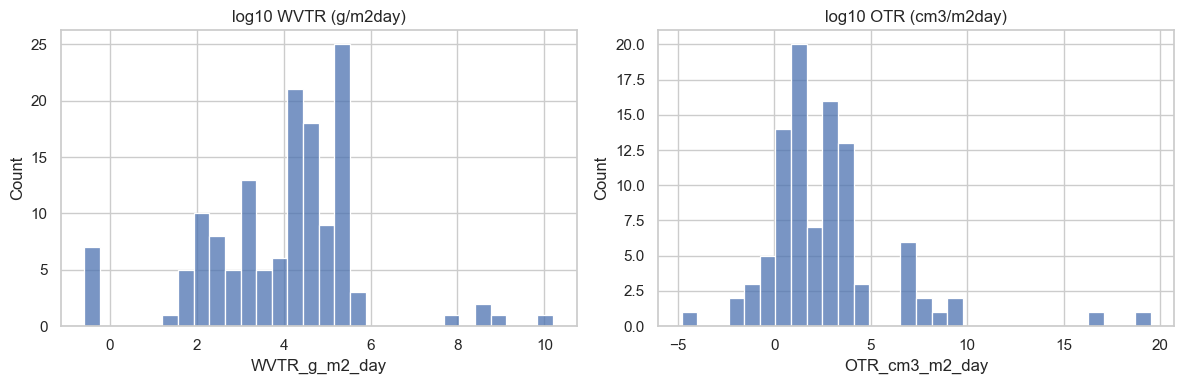

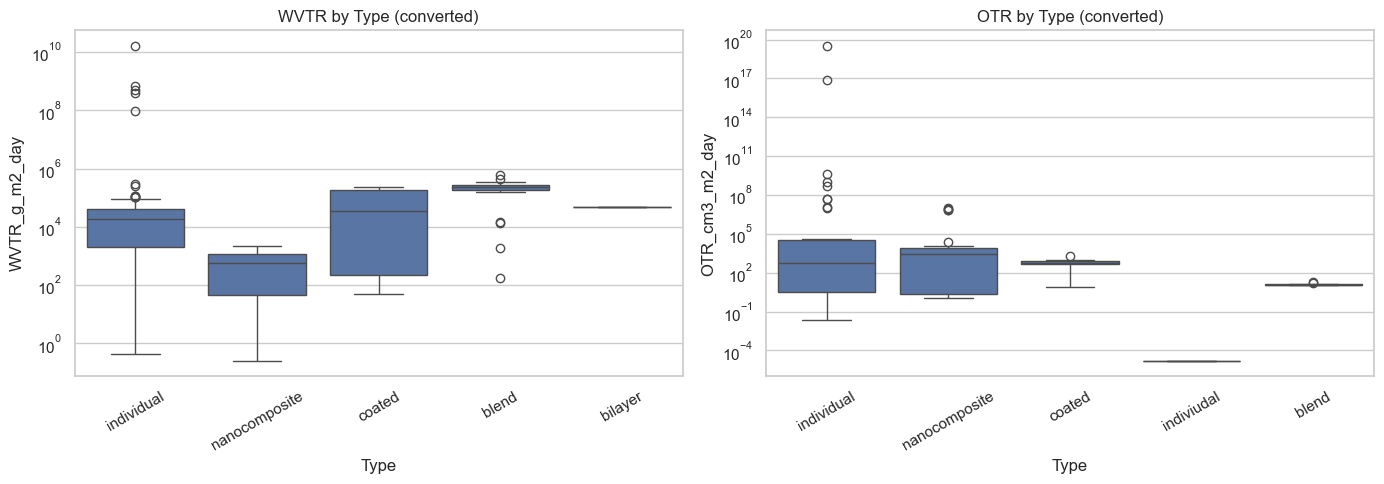

In [14]:
wvtr_bins = [0, 1, 10, 100, 1000, 1e4, 1e5, np.inf]
otr_bins = [0, 1, 10, 100, 1e3, 1e4, 1e6, np.inf]
wvtr_labels = ["<1", "1–10", "10–100", "100–1e3", "1e3–1e4", "1e4–1e5", ">1e5"]
otr_labels = ["<1", "1–10", "10–100", "100–1e3", "1e3–1e4", "1e4–1e6", ">1e6"]

mat["wvtr_bin"] = pd.cut(mat["WVTR_g_m2_day"], bins=wvtr_bins, labels=wvtr_labels, right=False)
mat["otr_bin"] = pd.cut(mat["OTR_cm3_m2_day"], bins=otr_bins, labels=otr_labels, right=False)
display(mat["wvtr_bin"].value_counts().sort_index().to_frame("count"))
display(mat["otr_bin"].value_counts().sort_index().to_frame("count"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(np.log10(mat["WVTR_g_m2_day"].dropna().clip(lower=1e-12)), bins=30, ax=axes[0])
axes[0].set_title("log10 WVTR (g/m2day)")
sns.histplot(np.log10(mat["OTR_cm3_m2_day"].dropna().clip(lower=1e-12)), bins=30, ax=axes[1])
axes[1].set_title("log10 OTR (cm3/m2day)")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=mat.dropna(subset=["WVTR_g_m2_day"]), x="Type", y="WVTR_g_m2_day", ax=axes[0])
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_title("WVTR by Type (converted)")
sns.boxplot(data=mat.dropna(subset=["OTR_cm3_m2_day"]), x="Type", y="OTR_cm3_m2_day", ax=axes[1])
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_title("OTR by Type (converted)")
plt.tight_layout()
plt.show()


## Alignment with food requirement bands
Assuming food `Min/Max_WVTR` are `g/m2day` and `Min/Max_OTR` are `cm3/m2day` (not stated in the CSV).

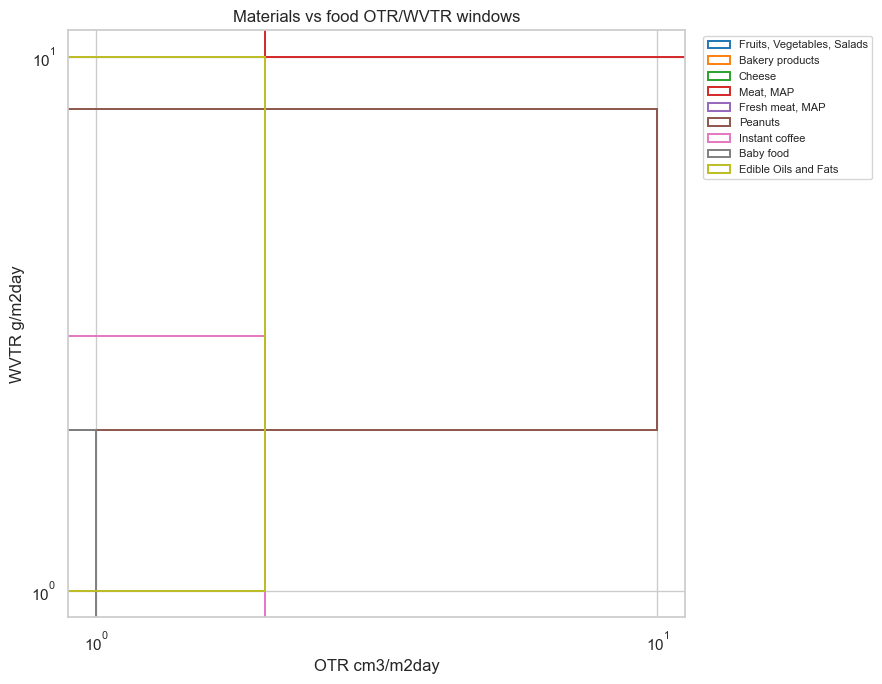

,Food_Category,n_mat_WVTR_in_band,n_mat_OTR_in_band,n_mat_both_in_band,Min_OTR,Max_OTR,Min_WVTR,Max_WVTR
0,"Fruits, Vegetables, Salads",43,5,0,10000.0,200000.0,10.0,3000.0
1,Bakery products,18,24,0,30.0,4000.0,600.0,3000.0
2,Cheese,4,1,0,7.0,10.0,300.0,600.0
3,"Meat, MAP",3,28,0,2.0,20.0,10.0,50.0
4,"Fresh meat, MAP",0,1,0,20.0,40.0,2.0,4.0
5,Peanuts,0,17,0,0.7,10.0,2.0,8.0
6,Instant coffee,0,10,0,0.2,2.0,0.7,3.0
7,Baby food,0,5,0,0.1,1.0,0.5,2.0
8,Edible Oils and Fats,0,11,0,0.1,2.0,1.0,10.0


Materials with comparable WVTR: 141
Materials with comparable OTR: 97
Spearman WVTR vs OTR (converted, paired): n/a


In [15]:
pair = mat.dropna(subset=["WVTR_g_m2_day", "OTR_cm3_m2_day"])
fig, ax = plt.subplots(figsize=(9, 7))
if len(pair):
    ax.scatter(pair["OTR_cm3_m2_day"], pair["WVTR_g_m2_day"], s=18, alpha=0.6, label="materials (both rates)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("OTR cm3/m2day")
ax.set_ylabel("WVTR g/m2day")

colors = sns.color_palette("tab10", n_colors=len(reqs))
for (i, r), color in zip(reqs.iterrows(), colors):
    x0, x1 = r["Min_OTR"], r["Max_OTR"]
    y0, y1 = r["Min_WVTR"], r["Max_WVTR"]
    ax.add_patch(plt.Rectangle((x0, y0), max(x1 - x0, x0 * 1e-6), max(y1 - y0, y0 * 1e-6),
                               fill=False, edgecolor=color, linewidth=1.4, label=r["Food_Category"]))
ax.set_title("Materials vs food OTR/WVTR windows")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

rows = []
for _, r in reqs.iterrows():
    w = mat["WVTR_g_m2_day"].between(r["Min_WVTR"], r["Max_WVTR"])
    o = mat["OTR_cm3_m2_day"].between(r["Min_OTR"], r["Max_OTR"])
    rows.append({
        "Food_Category": r["Food_Category"],
        "n_mat_WVTR_in_band": int(w.sum()),
        "n_mat_OTR_in_band": int(o.sum()),
        "n_mat_both_in_band": int((w & o).sum()),
        "Min_OTR": r["Min_OTR"], "Max_OTR": r["Max_OTR"],
        "Min_WVTR": r["Min_WVTR"], "Max_WVTR": r["Max_WVTR"],
    })
cover = pd.DataFrame(rows)
display(cover)

print("Materials with comparable WVTR:", int(mat["wvtr_comparable"].sum()))
print("Materials with comparable OTR:", int(mat["otr_comparable"].sum()))
print("Spearman WVTR vs OTR (converted, paired):",
      pair[["WVTR_g_m2_day", "OTR_cm3_m2_day"]].corr(method="spearman").iloc[0, 1] if len(pair) > 2 else "n/a")


## Findings to carry forward
- Do not compare raw `WVTR`/`OTR` across rows until units are unified.
- Food requirement units are **assumed**, not stored.
- Permeability-style OTR units cannot join food bands without thickness.
- IQR outliers on mixed-unit data are not physical outliers.